In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [10]:
# 1. Chargement du nouveau dataset (Fashion MNIST)
# Classes : T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = np.expand_dims(X_train, -1) #pour dire qu'il n y a que le gris comme couleur car conv2D arrend une structure 3D
X_test = np.expand_dims(X_test, -1)

In [12]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),

    # + de filtres pour capter la cmplx des vetements
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    
    # aide pour eviter l overfitting
    keras.layers.Dropout(0.5), 
    
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5, # On peut monter à 10 car le Dropout protège le modèle
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.7977 - loss: 0.5541 - val_accuracy: 0.8557 - val_loss: 0.3948
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8590 - loss: 0.3852 - val_accuracy: 0.8810 - val_loss: 0.3171
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8769 - loss: 0.3363 - val_accuracy: 0.8847 - val_loss: 0.3053
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8891 - loss: 0.3040 - val_accuracy: 0.8945 - val_loss: 0.2812
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8946 - loss: 0.2836 - val_accuracy: 0.8958 - val_loss: 0.2765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9004 - loss: 0.2690 - val_accuracy: 0.9042 - val_loss: 0.2595
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9050 - loss: 0.2554 - val_accuracy: 0.9013 - val_loss: 0.2566
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9089 - loss: 0.2433 - 

In [14]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


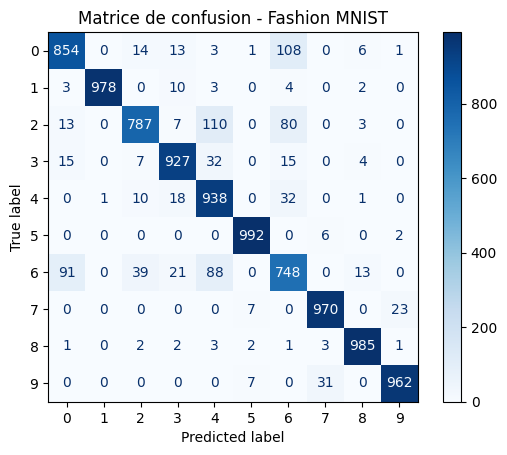


Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.92      0.79      0.85      1000
           3       0.93      0.93      0.93      1000
           4       0.80      0.94      0.86      1000
           5       0.98      0.99      0.99      1000
           6       0.76      0.75      0.75      1000
           7       0.96      0.97      0.97      1000
           8       0.97      0.98      0.98      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



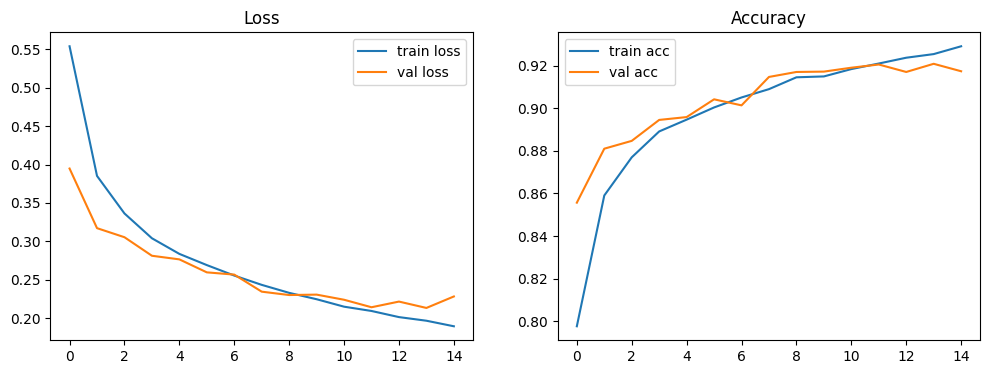

In [15]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Fashion MNIST")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.legend()
plt.show()

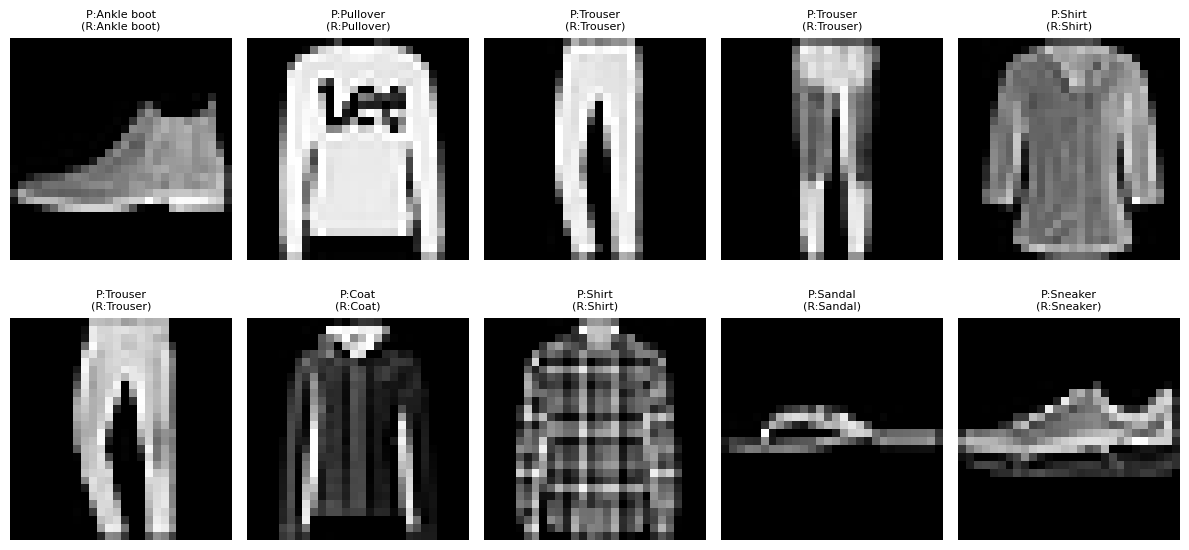

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"P:{class_names[y_pred[i]]}\n(R:{class_names[y_test[i]]})", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()